In [1]:
## 1. Data Loading and Preprocessing

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')


In [2]:

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [3]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
model_names = []
accuracies = []

In [5]:
## 2. Logistic Regression

print("--- Logistic Regression ---")
lr_params = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear']}
lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5, scoring='accuracy')
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.decision_function(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
model_names.append('Logistic Regression')
accuracies.append(acc_lr)

print(f"Best Params: {lr_grid.best_params_}")
print()

print(f"Accuracy: {acc_lr:.4f}")
print()

print(classification_report(y_test, y_pred_lr, target_names=target_names))
print()

print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_lr))


--- Logistic Regression ---
Best Params: {'C': 1, 'solver': 'liblinear'}

Accuracy: 0.9825

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


confusion_matrix:
[[41  1]
 [ 1 71]]


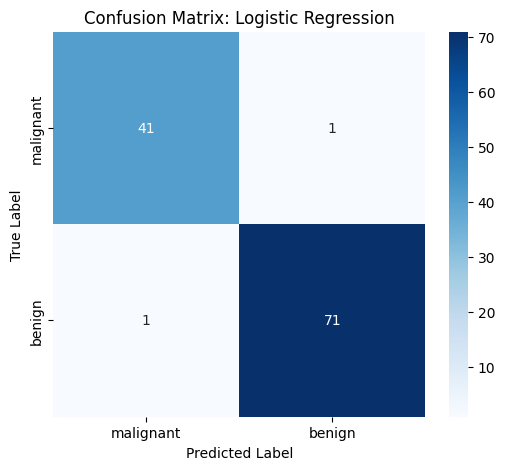

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:

## 3. K-Nearest Neighbors (KNN)

print("--- K-Nearest Neighbors ---")
knn_params = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
model_names.append('KNN')
accuracies.append(acc_knn)

print(f"Best Params: {knn_grid.best_params_}")
print(f"Accuracy: {acc_knn:.4f}")
print(classification_report(y_test, y_pred_knn, target_names=target_names))

print()

print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_knn))

--- K-Nearest Neighbors ---
Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Accuracy: 0.9825
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


confusion_matrix:
[[40  2]
 [ 0 72]]


In [8]:

## 4. Support Vector Machine (SVM)

print("--- Support Vector Machine ---")
svm_params = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.decision_function(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
model_names.append('SVM')
accuracies.append(acc_svm)

print(f"Best Params: {svm_grid.best_params_}")
print(f"Accuracy: {acc_svm:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=target_names))


print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_svm))


--- Support Vector Machine ---
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.9825
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

confusion_matrix:
[[41  1]
 [ 1 71]]


In [9]:

## 5. Decision Tree

print("--- Decision Tree ---")
dt_params = {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train_scaled, y_train)

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)
y_prob_dt = best_dt.predict_proba(X_test_scaled)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
model_names.append('Decision Tree')
accuracies.append(acc_dt)

print(f"Best Params: {dt_grid.best_params_}")
print(f"Accuracy: {acc_dt:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

print()

print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_dt))


--- Decision Tree ---
Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Accuracy: 0.9211
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


confusion_matrix:
[[39  3]
 [ 6 66]]


In [10]:

## 6. Random Forest

print("--- Random Forest ---")
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'max_features': ['sqrt', 'log2']}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
model_names.append('Random Forest')
accuracies.append(acc_rf)

print(f"Best Params: {rf_grid.best_params_}")
print(f"Accuracy: {acc_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

print()

print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_rf))


--- Random Forest ---
Best Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


confusion_matrix:
[[39  3]
 [ 2 70]]


In [11]:
## 7. AdaBoost

print("--- AdaBoost ---")
ada_params = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42, algorithm='SAMME'), ada_params, cv=5, scoring='accuracy')
ada_grid.fit(X_train_scaled, y_train)

best_ada = ada_grid.best_estimator_
y_pred_ada = best_ada.predict(X_test_scaled)
y_prob_ada = best_ada.predict_proba(X_test_scaled)[:, 1]

acc_ada = accuracy_score(y_test, y_pred_ada)
model_names.append('AdaBoost')
accuracies.append(acc_ada)

print(f"Best Params: {ada_grid.best_params_}")
print(f"Accuracy: {acc_ada:.4f}")
print(classification_report(y_test, y_pred_ada, target_names=target_names))


print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_ada))

--- AdaBoost ---


TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'algorithm'

In [ ]:
## 8. Final Comparison

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['blue', 'green', 'red', 'orange', 'purple', 'brown'])
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Classification Models on Breast Cancer Dataset')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

plt.show()

In [ ]:
#  Creating and Sorting the DataFrame


models_data = [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('KNN', y_pred_knn, y_prob_knn),
    ('SVM', y_pred_svm, y_prob_svm),
    ('Decision Tree', y_pred_dt, y_prob_dt),
    ('Random Forest', y_pred_rf, y_prob_rf),
    ('AdaBoost', y_pred_ada, y_prob_ada)
]

metrics_list = []

for name, preds, probs in models_data:
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    metrics_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': roc_auc
    })
    
res_df = pd.DataFrame(metrics_list)
res_df = res_df.sort_values(by='AUC', ascending=False).reset_index(drop=True)
res_df
